# Craig Transform

Transforming $G_{UV},\,G_{NE}$ to $g_{D}$

## Theory

### The Craig transform

The Craig transform provides functionality to generate gravity from differential curvatures.

This tutorial demonstrates its use on publicly available data (resources.vic.gov.au) from the Fosterville Falcon airborne gravity gradiometer survey.

The Craig transform calculates any or all components of the gravity gradient and the gravity acceleration from measured differential curvature gradients. The transform is performed in the wavenumber domain using the Fourier transform. The gravity gradient tensor is derived from:

$$\mathcal{F}\left(\Gamma\right)=\frac{2}{\left(k_{N}+i k_{E}\right)^{2}}\begin{bmatrix}k_N^2 & k_N k_E & ik_N k \\ & k_E^2 & i k_E k \\  &  & -k^2 \\\end{bmatrix}\mathcal{F}\left(\Gamma_{UV}+i \Gamma_{NE}\right)$$

and the gravitational acceleration vector from

$$\mathcal{F}\left(\mathbf{g}\right)=\frac{2}{\left(k_{N}+i k_{E}\right)^{2}}\begin{bmatrix}-ik_N & -ik_E & -k \end{bmatrix}\mathcal{F}\left(\Gamma_{UV}+i \Gamma_{NE}\right)$$

where $k=\sqrt{k_N^2+k_E^2}$ is the radial wavenumber on the horizontal plane.

The implementation here only derives the vertical gravitational acceleration:

$$\mathcal{F}\left(g_D\right)=\frac{-2k}{\left(k_{N}+i k_{E}\right)^{2}}\mathcal{F}\left(\Gamma_{UV}+i \Gamma_{NE}\right)$$

The method proceeds in several steps.

1. The measured differential curvature ($\Gamma_{UV}$ and $\Gamma_{NE}$) data are separately gridded. This is done by minimum curvature with a default cell size 1/4 of the line spacing although the user may select their own value. Grid cells further than 3 cells from a located data value are marked "missing".

1. Each grid is padded to extend the size of the grid in all four directions, and to fill any missing data. The padding may be done by sampling from a regional gravity grid, by filling with the mean value, or by a constant value. Regional gravity padding provides the best result. The regional grid is transformed by the reverse Craig transform to the differential curvature components and interpolated onto the locations of the measured differential curvature grids.

1. The padded data are transformed to $g_D$ using the bottom equation above. Then the cells that were padded for the transform are marked as missing since they did not originally have a measured value. The grid is then trimmed to the smallest rectangle possible without removing good data.

1. This grid is sampled back to the `whizzFile` from which the differential curvature data originated.

Note that the method treats all data as though it is located on a horizontal plane. This is a good approximation for many airborne gravity gradient surveys but will give inaccurate results for surveys draped to follow rugged terrain.

For true potential fields, the inverse-transformed result is purely real. For real data however, the imaginary part is generally non-zero, reflecting errors in the data. It is useful therefore to check an image of the imaginary part of the output. It should be much smaller in amplitude than the real part.

### Masking

It is worth making some comments describing the masking of the data. Several issues are relevant:

1. The survey boundary may be quite complex (as the Fosterville example shows). One cannot expect a simple rectangle, nor vene a polygon or other convex shape. There may be holes (mathematically, the survey area might not be simply connected).
1. There may be missing data within the survey boundary.
1. The interpolation to grid routine will generally interpolate into holes and into areas of missing data.
1. The Craig transform requires a completely filled rectngle of data.
1. The padding for the Craig transform extends the data to the borders of a rectangle that is well beyond the survey boundary.
1. The final product should have missing data where the survey had missing data, and anywhere outside the survey boundary.

Accordingly, the code remembers the missing value area of the gridded data (called internally the `nanmask`) and, if provided, the survey boundary. The current iteration of the code only allows polygonal survey boundaries so holes are ignored in the survey boundary. Holes will be honoured if they are filled with missing-data values or have no data provided, although the grid interpolation will encroach into holes.

With regard to data coverage, the process looks like:

1. Interpolate Gne, Guv data to regular grid with missing data values at grid points further than some small fixed number of grid cells from located data.
2. Store the missing data mask as `nanmask`.
3. Pad the grids. Several methods are available but the recommended method pads to a large rectangle with regional Gne and Guv, using the regional data to also fill the missing data points.
4. Expand the nanmask to the same area.
5. Process the data to the final gD grid. This will cover the entire padded area.
6. Mask the missing data values according to nanmask.
7. If a survey boundary is provided, mask areas outside the survey boundary as missing value.
8. Trim the grid back to the smallest cardinal rectangle possible by trimming only missing values

### Conforming

## Fosterville Example

The Fosterville data were downloaded from Resources Victoria. The located data were in ASEG-GDF2 format and these were written to `whizzFile` in HDF5 format. Most channels were omitted to reduce the data volume. It is this minimalist data set that is used here. 

The regional data were extracted and downloaded from GADDS.

For no particular reason, this example uses the free-air data.

___
Import the required modules, and set the path to the geowhizz files.

In [40]:
from pathlib import Path
import pegasusQC as qc

data_root = r'./FostervilleData/'
FostervilleHDF_file = Path(data_root + r'Foster_craig.hdf5')
regional_fa_ers = Path(data_root + r'Gravmap2019-grid-grv_fa.ers')

In [2]:
if not FostervilleHDF_file.exists():
    print("Ask Mark for help!!!")

In [3]:
# Find the channel names for the free-air Gne and Guv data
qc.reportChannels(FostervilleHDF_file)

Whizz Version 1.0

8 channels:


8 channels:
['Elevation_GNSS_GRS80', 'Falc_A_NE_0p00_0p18Hz_MeanLev',
'Falc_A_UV_0p00_0p18Hz_MeanLev', 'Falc_gD_0p00_0p18HzLP_ESD300m_SDS',
'GNSS_Easting_WGS84UTM55', 'GNSS_Northing_WGS84UTM55',
'Smooth_Drape_Surface_EGM96', 'Time_SSM_UTC1980']


Reading located data from whizz file.
206 lines; total number of fids in whizz file = 366670.
    Falc_A_NE_0p00_0p18Hz_MeanLev: min = -51.8, max = 39.8, mean = 0.0262.

206 lines; total number of fids in whizz file = 366670.
    Falc_A_UV_0p00_0p18Hz_MeanLev: min = -41.5, max = 67.7, mean = -0.312.


Gridding Foster_craig data with cell size = 50.0.

Reading in the regional data.

Interpolating the local curvature gradients to grids.
Processing (x, y, z) = (GNSS_Easting_WGS84UTM55, GNSS_Northing_WGS84UTM55, Falc_A_NE_0p00_0p18Hz_MeanLev).
 Falc_A_NE_0p00_0p18Hz_MeanLev in unknown units.
Processing (x, y, z) = (GNSS_Easting_WGS84UTM55, GNSS_Northing_WGS84UTM55, Falc_A_UV_0p00_0p18Hz_MeanLev).
 Falc_A_UV_0p00_0p18Hz_MeanLev in unknown units.

Padding the local curvature gradient grids.
Wavenumber resolution = 8.88e-06
Equivalent wavelength = 7.07e+05 m.

Transforming the local curvature gradient grids to gravity.
Wavenumber resolution = -1.45e-05
Equivalent wavelength = -4.35e+05 m.

Co

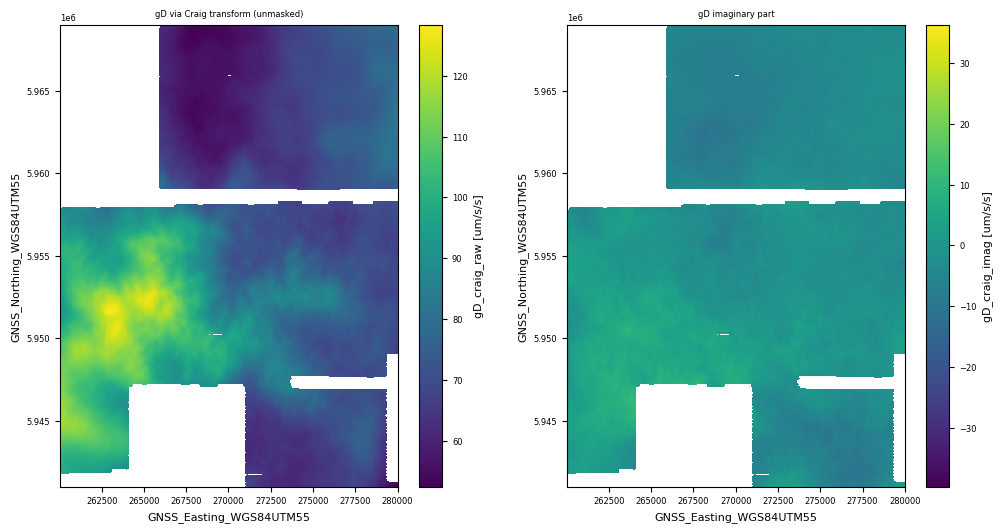

In [4]:
# Here we impose an artificial survey polygon to see the behaviour of the code.
gD_grid = qc.craig_transform(
    whizzFile=FostervilleHDF_file, 
    gne_chan='Falc_A_NE_0p00_0p18Hz_MeanLev', 
    guv_chan='Falc_A_UV_0p00_0p18Hz_MeanLev',
    gd_chan=None,
    result_units='um/s/s',
    survey_polygon=[
        (260000, 5941000),
        (280000, 5941000),
        (280000, 5969000),
        (260000, 5969000),
    ],
    pad_cells=256, 
    padding_mode="regional", 
    regional_grid_file=regional_fa_ers,
    regional_grav_units='gu',
    conforming=True,
)

___
It is a little easier to see the details if we image the final result as a shaded image (below). The results show a small imaginary part as expected, and the final gravity grid matches the regional gravity well while retaining the new short wavelength information from the survey.

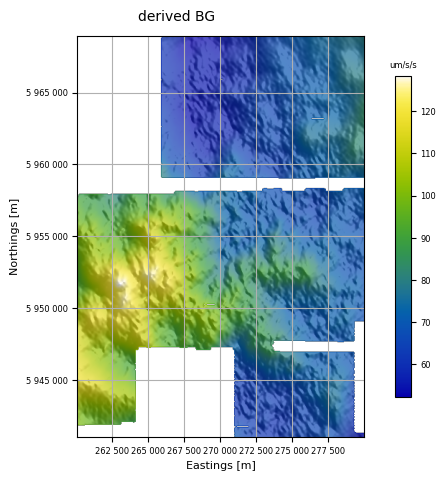

In [5]:
qc.xdImage(gD_grid, 'derived BG', hs=True)

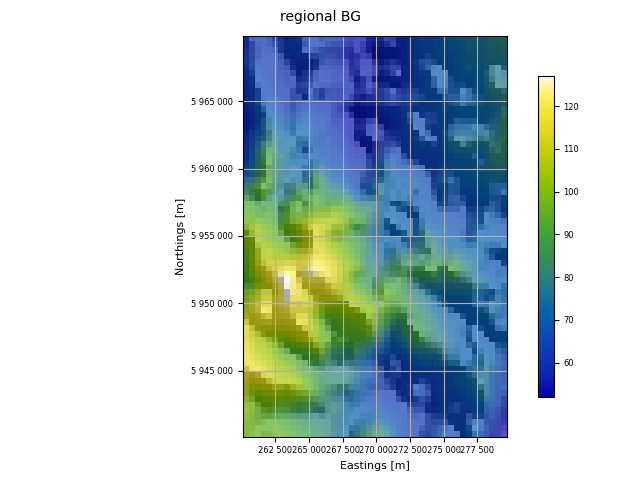

In [49]:
regional, _ = qc.gridfile_to_xa(regional_fa_ers)
cropped_regional = regional.sel(x=slice(260000, 280000), y=slice(5940000, 5970000))
qc.xdImage(cropped_regional, 'regional BG', hs=True)

## Telfer Example

The Telfer survey data were downloaded from the Geological Survey of Western Australia at https://geodownloads.dmp.wa.gov.au/downloads/geophysics/71234/, and the regional grid from GADDS. The data are complete Bouguer gravity.

In [15]:
from pathlib import Path
import pegasusQC as qc

data_root = r'./TelferData/'
TelferHDF_file = Path(data_root + r'Telfer_craig.hdf5')

# Downloaded from GADDS (complete Bouguer grid, 2019)
regional_cb_ers = Path(data_root + r'Gravmap2019-grid-grv_cscba.ers')

# The final conformed complete Bouguer by Xcalibur.
true_gd_ers = Path(data_root + r'2131_1_Fourier_gD_2p67_conformed_final.ers')

In [16]:
if not TelferHDF_file.exists():
    print("Ask Mark for help!!!")
    # %run ./Prepare_EastVicData.ipynb

In [17]:
# Find the channel names for the Gne and Guv data
qc.reportChannels(TelferHDF_file)

Whizz Version 1.0

11 channels:


11 channels:
['ALTITUDE_Ellipsoid', 'A_NE_0', 'A_NE_2p67', 'A_UV_0', 'A_UV_2p67',
'DRAPESURFACE_FOURIER', 'EASTING', 'FIDUCIAL', 'NORTHING',
'gD_FOURIER_0', 'gD_FOURIER_2p67']


In [18]:
mask_polygon = [(410898 , 7622722), (453935, 7575693), (433181, 7557737), (390139, 7604799)]

Reading located data from whizz file.
269 lines; total number of fids in whizz file = 1122946.
    A_NE_2p67: min = -161, max = 40.1, mean = -22.3.

269 lines; total number of fids in whizz file = 1122946.
    A_UV_2p67: min = -96.2, max = 52.7, mean = -28.9.


Reading in the regional data.

Interpolating the local curvature gradients to grids.
Processing (x, y, z) = (EASTING, NORTHING, A_NE_2p67).
 A_NE_2p67 in eotvos.
Processing (x, y, z) = (EASTING, NORTHING, A_UV_2p67).
 A_UV_2p67 in eotvos.

Padding the local curvature gradient grids.
Wavenumber resolution = 2.11e-06
Equivalent wavelength = 2.97e+06 m.

WARNING - grid statistical ranges suggest units error.


Transforming the local curvature gradient grids to gravity.
Wavenumber resolution = -6.75e-06
Equivalent wavelength = -9.3e+05 m.

Conforming the local gravity to the regional.
Parameters: low_lambda = 31898, hi_lambda = 38278, pad_cells = 797
Regional grid Wavenumber resolution = -3.7e-06
              Equivalent wavelength 

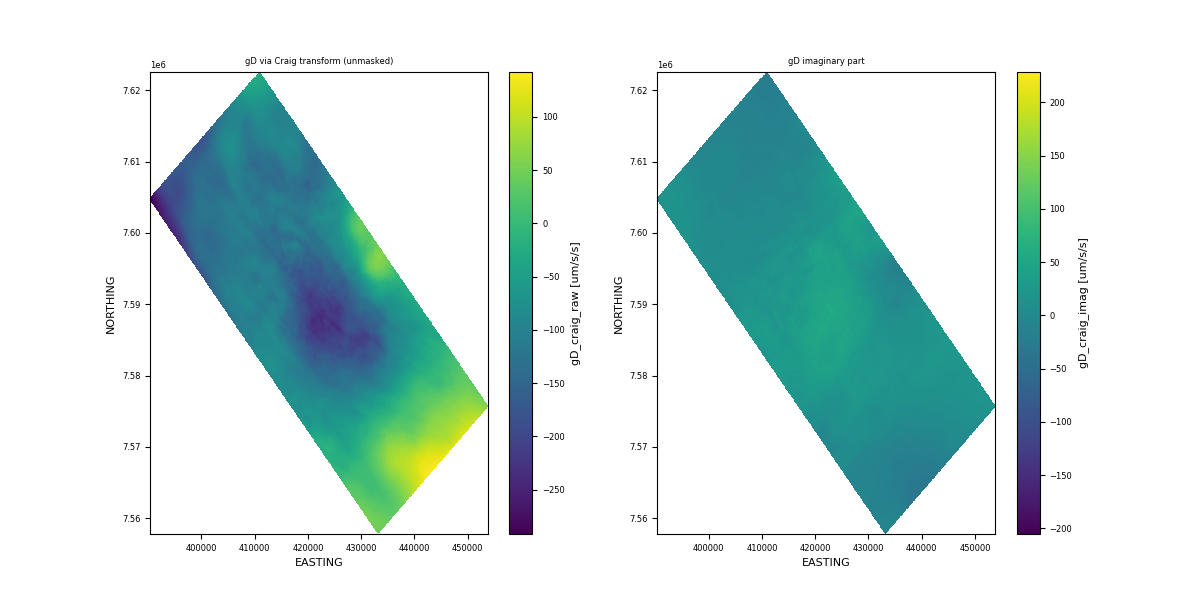

In [19]:
gD_grid = qc.craig_transform(
    whizzFile=TelferHDF_file,
    gne_chan='A_NE_2p67',
    guv_chan='A_UV_2p67',
    gd_chan=None,
    cell_size=80.0,
    result_units='um/s/s',
    survey_polygon=mask_polygon,
    pad_cells=256,
    padding_mode="regional",
    regional_grid_file=regional_cb_ers,
    regional_grav_units='um/s/s',
    conforming=True,
)

For Telfer, we have the final conformed complete Bouguer data as supplied by the survey provider so we can compare it with our result.

Below are shaded images of the survey provider's result (the "true BG") multiplied by 10.0 to convert the data to um/s/s, and of our result. They look very similar but the colorbars suggest some difference.

Below the images are grid reports. The "true" result has a very similar standard deviation and mean but a larger range. It also has a smaller cell size. It is reasonable to suppose that the smaller cell size has allowed more extreme values so this is a possible explanation for the larger range.

Either way, our result is very similar and certainly acceptable.

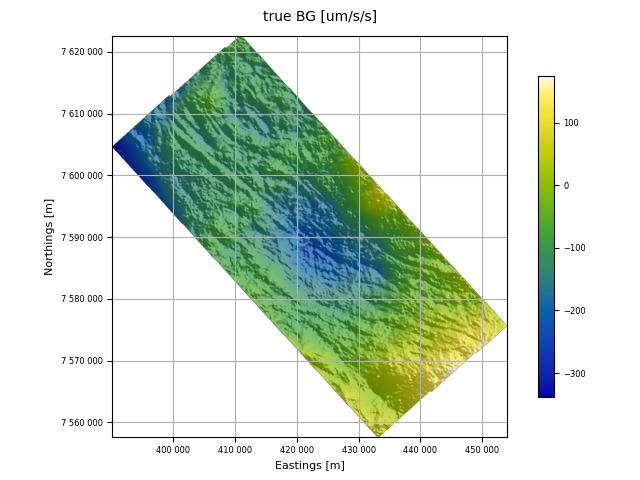

In [30]:
true_bg, _ = qc.gridfile_to_xa(true_gd_ers)
qc.xdImage(true_bg*10, 'true BG [um/s/s]')

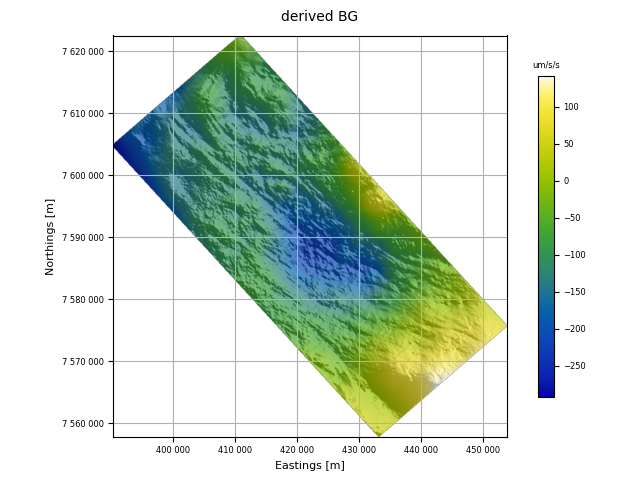

In [31]:
qc.xdImage(gD_grid, 'derived BG', hs=True)

In [32]:
from pegasusQC.gridFiles.gridutility import report_gridStats
report_gridStats(gD_grid)

RMS of result = 78.69 um/s/s
mean of result = -81.72 um/s/s
min of result = -291.67 um/s/s
max of result = 142.15 um/s/s
Array shape = (810, 794); number of cells = 643140
exscribed rectangle:
  [390385, [7557820],
  [453825, [7557820],
  [453825, [7622540],
  [390385, [7622540]
cell spacing = 80
number of NaNs = 369964


In [33]:
report_gridStats(true_bg*10)

RMS of result = 78.41
mean of result = -83.97
min of result = -337.59
max of result = 174.92
Array shape = (1040, 1022); number of cells = 1062880
exscribed rectangle:
  [390125, [7557688],
  [453938, [7557688],
  [453938, [7622625],
  [390125, [7622625]
cell spacing = 62
number of NaNs = 611781
